# Reproducing the Well Clear threshold results

Every table and figure in *Data-Driven Validation of DO-365 Detect-and-Avoid Well
Clear Thresholds for UAS in Terminal Airspace Using One Million Encounters*,
regenerated from the LLTEM V1.0 dataset.

Section numbers below match the manuscript. Run the notebook top to bottom.
Section 4 (preprocessing) takes roughly an hour on 60,000 encounters and caches
its result, so sections 5 onward can be re-run without repeating it.

**Before running:** download the two LLTEM files named in the README into
`data/`. The 18 GB trajectory archive is read member by member and is never
extracted.

## 1. Setup

In [1]:
import json
import zipfile
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import lltem_preprocessing as pre
import well_clear_analysis as wca

DATA_DIR = Path('data')
RESULTS_DIR = Path('results')
FIGURES_DIR = Path('figures')
RESULTS_DIR.mkdir(exist_ok=True)
FIGURES_DIR.mkdir(exist_ok=True)

INFO_PATH = DATA_DIR / 'terminal_encounter_info_20200630.csv'
ZIP_PATH = DATA_DIR / 'terminal_encounter_state_data_20200630.zip'
CACHE_PATH = RESULTS_DIR / 'stacked_cache.npz'

SAMPLE_SIZE = 60000
SEED = 42

plt.rcParams.update({'pdf.fonttype': 42, 'ps.fonttype': 42, 'font.size': 10})


def save_json(obj, name):
    with open(RESULTS_DIR / name, 'w') as f:
        json.dump(obj, f, indent=2, default=str)
    print(f'wrote results/{name}')


for p in (INFO_PATH, ZIP_PATH):
    print(f'{"found  " if p.exists() else "MISSING"} {p}')

found   data\terminal_encounter_info_20200630.csv
found   data\terminal_encounter_state_data_20200630.zip


## 2. Population characterization

Population-scale results use all 1,000,000 encounters and come from LLTEM's own
CPA metadata, which is exact rather than re-derived. Only the time-series
results need the trajectory archive.

`scalar_cpa_metrics` is the right entry point here rather than labelling the
metadata columns directly: `vmd_ft` is *signed* (negative when the intruder
passes below the ownship, which is true of 268,241 encounters), and severity is
defined on the magnitude of the vertical miss distance. Labelling the raw
column would count a 60 ft separation below as a 60 ft violation and a −60 ft
one as satisfying every threshold, roughly doubling the apparent NMAC count.

In [2]:
info = pd.read_csv(INFO_PATH)
info.columns = info.columns.str.strip()

population = wca.scalar_cpa_metrics(info)
geometry_all = population['geometry'].values
severity_all = population['severity'].values

geom_counts = pd.Series(geometry_all).value_counts()
sev_counts = pd.Series(severity_all).value_counts()

print(f'population: {len(info):,} encounters\n')
print('geometry')
for k, v in geom_counts.items():
    print(f'  {k:<12} {v:>9,} ({100 * v / len(info):5.1f}%)')
print('\nseverity')
for k in ('Safe', 'Unsafe', 'Hazardous'):
    v = int(sev_counts.get(k, 0))
    print(f'  {k:<12} {v:>9,} ({100 * v / len(info):5.2f}%)')

save_json({'n_population': int(len(info)),
           'geometry': {k: int(v) for k, v in geom_counts.items()},
           'severity': {k: int(sev_counts.get(k, 0))
                        for k in ('Safe', 'Unsafe', 'Hazardous')}},
          'population_summary.json')

population: 1,000,000 encounters

geometry
  head-on        644,309 ( 64.4%)
  overtaking     202,987 ( 20.3%)
  crossing       152,704 ( 15.3%)

severity
  Safe           802,981 (80.30%)
  Unsafe         189,784 (18.98%)
  Hazardous        7,235 ( 0.72%)
wrote results/population_summary.json


## 3. Sample design

An equal quota per geometry class, drawn from the *unfiltered* population under
a fixed seed. Drawing from the full population rather than a pre-filtered
"close encounters" pool keeps the sample spanning the whole severity range.

No model is fitted anywhere in this analysis, so the sample is not split into
training and validation subsets.

In [3]:
selected = pre.draw_stratified_sample(info, geometry_all,
                                      n_total=SAMPLE_SIZE, seed=SEED)
print(f'sampled {len(selected):,} encounters, seed {SEED}\n')
print(selected['geometry'].value_counts().to_string())

sampled 60,000 encounters, seed 42

geometry
head-on       20000
overtaking    20000
crossing      20000


## 4. Preprocessing

Load each encounter's two state files, build the relative state, window it
±60 s about the metadata CPA time, resample to a uniform 1 Hz grid, and smooth
with a Savitzky–Golay filter (order 3, window 7) whose analytic derivative
supplies the range rate.

The correct column alignment matters here: the raw CSVs carry a trailing comma,
so each row parses into 16 fields rather than 15. See the docstring of
`lltem_preprocessing.load_encounter_pair`.

In [4]:
if CACHE_PATH.exists():
    cached = np.load(CACHE_PATH, allow_pickle=True)
    extra = ('severity', 'turn_rate_max')
    stacked = {k: cached[k] for k in cached.files if k not in extra}
    severity = cached['severity'].astype(object)
    turn_rate_max = cached['turn_rate_max']
    print(f'loaded cache: {len(severity):,} encounters')
else:
    with zipfile.ZipFile(ZIP_PATH) as zf:
        aligned, turn_rate_max, dropped_short, failed = pre.preprocess_encounters(zf, selected)

    print(f'\nretained {len(aligned):,} of {len(selected):,} '
          f'({100 * len(aligned) / len(selected):.2f}%)')
    print(f'dropped (CPA at window edge): {len(dropped_short):,}')
    print(f'unreadable: {len(failed):,}')

    stacked, severity, _ = wca.build_sample_metrics(aligned)
    np.savez_compressed(CACHE_PATH,
                        severity=np.asarray(severity).astype(str),
                        turn_rate_max=turn_rate_max, **stacked)
    print(f'\ncached to {CACHE_PATH}')

# `stacked` already carries a geometry label per encounter, so the cached and
# freshly-computed paths agree on it without storing it twice.
geometry = np.asarray(stacked['geometry'], dtype=object)

   2,000/60,000  elapsed    13s  eta   373s


   4,000/60,000  elapsed    26s  eta   358s


   6,000/60,000  elapsed    38s  eta   344s


   8,000/60,000  elapsed    51s  eta   334s


  10,000/60,000  elapsed    65s  eta   323s


...

  54,000/60,000  elapsed   366s  eta    41s


  56,000/60,000  elapsed   381s  eta    27s


  58,000/60,000  elapsed   396s  eta    14s


  done in 6.9 min: 60,000 retained, 0 short-window, 0 unreadable

retained 60,000 of 60,000 (100.00%)
dropped (CPA at window edge): 0
unreadable: 0



cached to results\stacked_cache.npz


In [5]:
meta = selected.set_index('id').loc[stacked['encounter_id']]
corr = np.corrcoef(stacked['r_h_min'], meta['hmd_ft'].values)[0, 1]
median_err = float(np.median(np.abs(stacked['r_h_min'] - meta['hmd_ft'].values)))

print('trajectory-derived CPA vs. LLTEM metadata')
print(f'  correlation      {corr:.4f}')
print(f'  median |diff|    {median_err:.0f} ft')
assert corr > 0.99, 'trajectory CPA does not track the metadata'

trajectory-derived CPA vs. LLTEM metadata
  correlation      0.9993
  median |diff|    46 ft


## 5. CPA metrics and severity labeling

In [6]:
sev_counts = pd.Series(severity).value_counts()
n = len(severity)
print(f'sample: {n:,} encounters\n')
for k in ('Safe', 'Unsafe', 'Hazardous'):
    v = int(sev_counts.get(k, 0))
    print(f'  {k:<12} {v:>7,} ({100 * v / n:5.2f}%)')

print('\nhazard prevalence by geometry')
for g in pd.unique(geometry):
    m = np.asarray(geometry) == g
    haz = int(np.sum(np.asarray(severity)[m] == 'Hazardous'))
    print(f'  {g:<12} {haz:>5,} of {m.sum():,} ({100 * haz / m.sum():.2f}%)')

save_json({'n_sample': int(n),
           'severity': {k: int(sev_counts.get(k, 0))
                        for k in ('Safe', 'Unsafe', 'Hazardous')}},
          'sample_summary.json')

sample: 60,000 encounters

  Safe          47,267 (78.78%)
  Unsafe        12,097 (20.16%)
  Hazardous        636 ( 1.06%)

hazard prevalence by geometry
  head-on         59 of 20,000 (0.29%)
  overtaking     398 of 20,000 (1.99%)
  crossing       179 of 20,000 (0.90%)
wrote results/sample_summary.json


## 6. Threshold evaluation — baseline vs. Vincent et al. (Table 1)

An alert counts as a positive NMAC prediction only if it fires at the fixed
NMAC scale (500 ft / 100 ft), evaluated using the configuration's own TAUMOD.
That keeps two claims apart: an alert correctly flagging a 1000 ft Well Clear
violation is not scored as a false NMAC prediction.

In [7]:
overall_df, overall_crosstabs = wca.evaluate_named_configs_region(stacked, severity)
table1 = overall_df[['config', 'DMOD', 'ZTHR', 'TAUMOD',
                     'TP', 'FP', 'TN', 'FN', 'FPR', 'Precision']]
print(table1.to_string(index=False))

overall_df.to_csv(RESULTS_DIR / 'named_region_metrics.csv', index=False)
save_json(overall_df.to_dict(orient='records'), 'named_region_metrics.json')

                                        config   DMOD  ZTHR  TAUMOD  TP   FP    TN  FN      FPR  Precision
                    En-route baseline (DO-365) 4000.0 450.0    35.0 636 1679 57685   0 0.028283   0.274730
  Vincent et al. minimum (HMD=1000ft, tau=15s) 1000.0 450.0    15.0 636  546 58818   0 0.009197   0.538071
  Vincent et al. maximum (HMD=2000ft, tau=25s) 2000.0 450.0    25.0 636 1046 58318   0 0.017620   0.378121
Below-Vincent comparison (HMD=1000ft, tau=10s) 1000.0 450.0    10.0 636  346 59018   0 0.005828   0.647658
wrote results/named_region_metrics.json


## 7. Detection performance by encounter geometry (Table 2)

In [8]:
geom_df, _ = wca.evaluate_named_configs_region(stacked, severity, group_labels=geometry)
table2 = geom_df[geom_df['group'] != '__all__'][
    ['config', 'group', 'TP', 'FP', 'TN', 'FPR', 'Precision']]
print(table2.to_string(index=False))

geom_df.to_csv(RESULTS_DIR / 'named_region_metrics_by_geometry.csv', index=False)
save_json(geom_df.to_dict(orient='records'), 'named_region_metrics_by_geometry.json')

                                        config      group  TP  FP    TN      FPR  Precision
                    En-route baseline (DO-365)    head-on  59 212 19729 0.010631   0.217712
                    En-route baseline (DO-365) overtaking 398 944 18658 0.048158   0.296572
                    En-route baseline (DO-365)   crossing 179 523 19298 0.026386   0.254986
  Vincent et al. minimum (HMD=1000ft, tau=15s)    head-on  59  56 19885 0.002808   0.513043
  Vincent et al. minimum (HMD=1000ft, tau=15s) overtaking 398 346 19256 0.017651   0.534946
  Vincent et al. minimum (HMD=1000ft, tau=15s)   crossing 179 144 19677 0.007265   0.554180
  Vincent et al. maximum (HMD=2000ft, tau=25s)    head-on  59 117 19824 0.005867   0.335227
  Vincent et al. maximum (HMD=2000ft, tau=25s) overtaking 398 620 18982 0.031629   0.390963
  Vincent et al. maximum (HMD=2000ft, tau=25s)   crossing 179 309 19512 0.015590   0.366803
Below-Vincent comparison (HMD=1000ft, tau=10s)    head-on  59  37 19904 0.001855

## 8. Reweighting to the population geometry distribution (Table 3)

The sample is drawn on an equal geometry quota, so its mix differs from the
population's. Since the false-alarm rate varies by geometry, the pooled sample
figure is not an estimate of the population figure.

In [9]:
reweighted = wca.population_reweighted_fpr_region(stacked, severity, geometry)
print(reweighted.to_string(index=False))

reweighted.to_csv(RESULTS_DIR / 'population_reweighted_fpr_region.csv', index=False)
save_json(reweighted.to_dict(orient='records'), 'population_reweighted_fpr_region.json')

                                        config   DMOD  ZTHR  TAUMOD  fpr_sample_raw  fpr_population_reweighted  fpr_head-on  fpr_overtaking  fpr_crossing
                    En-route baseline (DO-365) 4000.0 450.0    35.0        0.028283                   0.020655     0.010631        0.048158      0.026386
  Vincent et al. minimum (HMD=1000ft, tau=15s) 1000.0 450.0    15.0        0.009197                   0.006502     0.002808        0.017651      0.007265
  Vincent et al. maximum (HMD=2000ft, tau=25s) 2000.0 450.0    25.0        0.017620                   0.012581     0.005867        0.031629      0.015590
Below-Vincent comparison (HMD=1000ft, tau=10s) 1000.0 450.0    10.0        0.005828                   0.004149     0.001855        0.011019      0.004692
wrote results/population_reweighted_fpr_region.json


## 9. What the false positives actually are (§5.3)

An alert that fails the NMAC test has not necessarily failed at its job — it
may have flagged a genuine Well Clear violation. This decomposes each
configuration's false positives by the encounter's true severity, judged
against **that configuration's own** Well Clear volume.

Well Clear violation is not reported as a positive class. Every configuration
flags every violation of its own volume, for the same reason the NMAC
true-positive rate is 1.000: if the true CPA lies inside the volume, both gates
are satisfied at closest approach. The cell asserts that rather than assuming
it — `wcv_detection_own_volume` must come back exactly 1.0 for all four.

In [10]:
composition = wca.false_positive_composition(stacked)
print(composition[['config', 'n_alerts_nmac', 'tp_nmac', 'fp_total',
                   'fp_genuine_wcv', 'fp_truly_safe',
                   'frac_fp_genuine_wcv', 'safe_alert_rate']].to_string(index=False))

own = composition['wcv_detection_own_volume']
print(f'\nWCV detection against each configuration own volume: '
      f'{sorted(own.unique())}')
assert (own == 1.0).all(), 'expected 1.000 by construction for every configuration'
print('degenerate as expected, so not reported as a result')

composition.to_csv(RESULTS_DIR / 'false_positive_composition.csv', index=False)
save_json(composition.to_dict(orient='records'), 'false_positive_composition.json')

                                        config  n_alerts_nmac  tp_nmac  fp_total  fp_genuine_wcv  fp_truly_safe  frac_fp_genuine_wcv  safe_alert_rate
                    En-route baseline (DO-365)           2315      636      1679            1463            216             0.871352         0.003600
  Vincent et al. minimum (HMD=1000ft, tau=15s)           1182      636       546             447             99             0.818681         0.001650
  Vincent et al. maximum (HMD=2000ft, tau=25s)           1682      636      1046             882            164             0.843212         0.002733
Below-Vincent comparison (HMD=1000ft, tau=10s)            982      636       346             324             22             0.936416         0.000367

WCV detection against each configuration own volume: [np.float64(1.0)]
degenerate as expected, so not reported as a result
wrote results/false_positive_composition.json


## 10. Sensitivity to preprocessing choices (Table 4)

The Savitzky–Golay order and window are analyst choices, so the evaluation is
repeated under alternative settings on a subsample. Each setting re-runs the
derivative estimation on its own copy of the aligned encounters.

In [11]:
SENSITIVITY_N = 6000

raw_aligned = []
with zipfile.ZipFile(ZIP_PATH) as zf:
    for _, row in selected.iloc[:SENSITIVITY_N].iterrows():
        own, intr = pre.load_encounter_pair(zf, int(row['id']))
        a = pre.align_to_cpa(pre.extract_states(own, intr, int(row['id'])),
                             float(row['tcpa']))
        if a is not None:
            a['geometry'] = row['geometry']
            raw_aligned.append(a)
print(f'subsample for sensitivity: {len(raw_aligned):,} encounters\n')

sensitivity = wca.smoothing_sensitivity(raw_aligned)
baseline_rows = sensitivity[sensitivity['config'].str.contains('baseline')]
print(baseline_rows[['sg_window', 'sg_order', 'FPR', 'Precision']].to_string(index=False))
print(f"\nFPR spread across settings: {baseline_rows['FPR'].max() - baseline_rows['FPR'].min():.4f}")
print(f"precision spread:            {baseline_rows['Precision'].max() - baseline_rows['Precision'].min():.4f}")

sensitivity.to_csv(RESULTS_DIR / 'smoothing_sensitivity.csv', index=False)
save_json({'subset_n': len(raw_aligned),
           'results': sensitivity.to_dict(orient='records')},
          'smoothing_sensitivity.json')

subsample for sensitivity: 6,000 encounters



 sg_window  sg_order      FPR  Precision
         7         3 0.028297   0.272727
         5         2 0.027956   0.271930
        11         3 0.028278   0.259912
         9         4 0.028292   0.269565

FPR spread across settings: 0.0003
precision spread:            0.0128
wrote results/smoothing_sensitivity.json


## 11. Region classification and predicted-CPA accuracy (Tables 5 and 6)

Part A asks how well the complete alerting logic classifies overall severity.
Part B isolates the predictive term: is its forward-extrapolated CPA a good
estimate of the encounter's true CPA?

The pooled accuracy counts encounters the gate never engaged on as correctly
labelled Safe, and engagement varies sharply with configuration, so the
engaged-only column is the like-for-like comparison.

In [12]:
region_acc = []
for name, (dmod, zthr, taumod) in wca.NAMED_CONFIGS.items():
    ct = overall_crosstabs[(name, '__all__')]
    order = ['Hazardous', 'Unsafe', 'Safe']
    mat = ct.reindex(index=order, columns=order).fillna(0).values
    region_acc.append({'config': name,
                       'region_accuracy': float(np.trace(mat) / mat.sum())})
print(pd.DataFrame(region_acc).to_string(index=False))

save_json(region_acc, 'region_accuracy.json')

                                        config  region_accuracy
                    En-route baseline (DO-365)         0.866333
  Vincent et al. minimum (HMD=1000ft, tau=15s)         0.972767
  Vincent et al. maximum (HMD=2000ft, tau=25s)         0.934383
Below-Vincent comparison (HMD=1000ft, tau=10s)         0.983967
wrote results/region_accuracy.json


In [13]:
cpa, _cpa_confusion = wca.evaluate_predicted_cpa_configs(stacked)
cpa_all = cpa[cpa['group'] == '__all__']
print(cpa_all.to_string(index=False))

engaged = wca.predicted_cpa_accuracy_engaged(stacked)
print()
print(engaged[['config', 'frac_engaged', 'acc_pooled', 'acc_engaged',
               'over_alarm_engaged', 'under_alarm_engaged',
               'bias_engaged_ft', 'frac_nopred_true_safe']].to_string(index=False))

cpa.to_csv(RESULTS_DIR / 'predicted_cpa_accuracy.csv', index=False)
save_json(cpa.to_dict(orient='records'), 'predicted_cpa_accuracy.json')
save_json(engaged.to_dict(orient='records'), 'predicted_cpa_engaged_only.json')

                                        config   DMOD  ZTHR  TAUMOD   group     n  n_correct  accuracy  n_no_prediction  n_over_alarm  n_under_alarm  frac_over_alarm  frac_under_alarm  n_hazardous_missed  r_h_bias_ft  r_h_mae_ft  r_v_bias_ft  r_v_mae_ft  lead_time_mean_s
                    En-route baseline (DO-365) 4000.0 450.0    35.0 __all__ 60000      53454  0.890900            25636          5369           1177         0.089483          0.019617                   1 -1298.833184 1311.860191    22.077302   74.116116         20.286724
  Vincent et al. maximum (HMD=2000ft, tau=25s) 2000.0 450.0    25.0 __all__ 60000      56373  0.939550            39081          3280            347         0.054667          0.005783                   0  -719.182125  738.807488     8.533462   42.424028         14.775658
  Vincent et al. minimum (HMD=1000ft, tau=15s) 1000.0 450.0    15.0 __all__ 60000      58500  0.975000            50277          1381            119         0.023017          0.001983 


                                        config  frac_engaged  acc_pooled  acc_engaged  over_alarm_engaged  under_alarm_engaged  bias_engaged_ft  frac_nopred_true_safe
                    En-route baseline (DO-365)      0.572733    0.890900     0.809510            0.156239             0.034251     -1298.833184                    1.0
  Vincent et al. minimum (HMD=1000ft, tau=15s)      0.162050    0.975000     0.845727            0.142034             0.012239      -321.181932                    1.0
  Vincent et al. maximum (HMD=2000ft, tau=25s)      0.348650    0.939550     0.826617            0.156795             0.016588      -719.182125                    1.0
Below-Vincent comparison (HMD=1000ft, tau=10s)      0.113367    0.984417     0.862540            0.122170             0.015290      -211.996344                    1.0
wrote results/predicted_cpa_accuracy.json
wrote results/predicted_cpa_engaged_only.json


In [14]:
closure_peak = wca.peak_closing_speed(stacked)
closure_band, closure_edges = wca.stratify_by_quantile(
    closure_peak, 3, ['low closure', 'medium closure', 'high closure'])
turn_band, turn_edges = wca.stratify_by_quantile(
    turn_rate_max, 3, ['low turn', 'medium turn', 'high turn'])

print(f'closure tercile edges:   {np.round(closure_edges[1:-1], 1)} ft/s')
print(f'turn-rate tercile edges: {np.round(turn_edges[1:-1], 2)} deg/s')

strata = {'geometry': np.asarray(geometry),
          'closing speed': closure_band,
          'turn rate': turn_band}

baseline_only = {'En-route baseline (DO-365)':
                 wca.NAMED_CONFIGS['En-route baseline (DO-365)']}
strata_rows = []
for label, bands in strata.items():
    df, _ = wca.evaluate_predicted_cpa_configs(stacked, configs=baseline_only,
                                               group_labels=bands)
    for _, r in df[df['group'] != '__all__'].iterrows():
        strata_rows.append({'stratifier': label, 'level': r['group'],
                            'accuracy': r['accuracy'],
                            'over_alarm': r['frac_over_alarm'],
                            'r_h_bias_ft': r['r_h_bias_ft']})
strata_df = pd.DataFrame(strata_rows)
print()
print(strata_df.to_string(index=False))

strata_df.to_csv(RESULTS_DIR / 'predicted_cpa_strata.csv', index=False)
save_json(strata_df.to_dict(orient='records'), 'predicted_cpa_strata.json')

closure tercile edges:   [225.6 335.6] ft/s
turn-rate tercile edges: [4.96 5.99] deg/s



   stratifier          level  accuracy  over_alarm  r_h_bias_ft
     geometry        head-on  0.922650    0.063900  -850.474484
     geometry     overtaking  0.846400    0.120050 -1670.303629
     geometry       crossing  0.903650    0.084500 -1561.125221
closing speed   high closure  0.879400    0.104600 -1297.834218
closing speed    low closure  0.911600    0.064350 -1300.758820
closing speed medium closure  0.881700    0.099500 -1299.100391
    turn rate       low turn  0.915700    0.068350 -1215.935111
    turn rate    medium turn  0.889994    0.090955 -1345.613214
    turn rate      high turn  0.867007    0.109145 -1322.457235
wrote results/predicted_cpa_strata.json


## 12. Operational feasibility — alert rates and lead times

Lead time runs from the first alert to the encounter's own closest approach.
Both can fall anywhere inside the ±60 s window, so the quantity is bounded by
±120 s. Negative values are late alerts, not artefacts: the criterion is a
conjunction, so an encounter can pass its horizontal minimum while still
vertically separated and satisfy it only once vertical separation is lost.

In [15]:
feasibility = {}
for label, (dmod, zthr, taumod) in [
        ('baseline', (4000.0, 450.0, 35.0)),
        ('vincent_max', (2000.0, 450.0, 25.0)),
        ('vincent_min', (1000.0, 450.0, 15.0))]:
    ev = wca.evaluate_lowc_batch(stacked, dmod=dmod, zthr=zthr, taumod=taumod)
    feasibility[label] = wca.lead_time_distribution(ev)

for k, v in feasibility.items():
    print(f"{k:<12} alerted {v['n_alerted']:>6,} ({v['alert_rate']:.4f})  "
          f"lead mean {v['lead_mean']:5.1f}  p10 {v['lead_p10']:4.0f}  "
          f"p50 {v['lead_p50']:4.0f}  p90 {v['lead_p90']:4.0f}  "
          f"range [{v['lead_min']:.0f}, {v['lead_max']:.0f}]  "
          f"negative {100 * v['frac_negative_lead']:.2f}%")

save_json(feasibility, 'operational_feasibility.json')

baseline     alerted 19,290 (0.3215)  lead mean  34.6  p10   10  p50   37  p90   59  range [-64, 117]  negative 5.12%
vincent_max  alerted  9,480 (0.1580)  lead mean  26.4  p10    9  p50   26  p90   47  range [-64, 117]  negative 4.28%
vincent_min  alerted  4,526 (0.0754)  lead mean  17.1  p10    7  p50   16  p90   28  range [-64, 117]  negative 2.78%
wrote results/operational_feasibility.json


In [16]:
curve, curve_summary = wca.fpr_vs_taumod(stacked, severity)
print(curve.to_string(index=False))
print()
print(f"FPR range over TAUMOD           : {curve_summary['fpr_min']:.4f} .. {curve_summary['fpr_max']:.4f}")
print(f"max FPR spread across DMOD      : {curve_summary['max_fpr_spread_across_dmod']:.2e}")
print(f"TPR = 1.000 at every grid point : {curve_summary['tpr_always_one']}")

curve.to_csv(RESULTS_DIR / 'fpr_vs_taumod.csv', index=False)
save_json({'curve': curve.to_dict(orient='records'), **curve_summary},
          'fpr_vs_taumod.json')

 TAUMOD  FPR_dmod500  TPR_dmod500  FPR_dmod1000  TPR_dmod1000  FPR_dmod4000  TPR_dmod4000  FPR_dmod6000  TPR_dmod6000
    0.0     0.001583          1.0      0.001583           1.0      0.001583           1.0      0.001583           1.0
    5.0     0.002998          1.0      0.002998           1.0      0.002998           1.0      0.002998           1.0
   10.0     0.005828          1.0      0.005828           1.0      0.005828           1.0      0.005828           1.0
   15.0     0.009197          1.0      0.009197           1.0      0.009197           1.0      0.009197           1.0
   20.0     0.013325          1.0      0.013325           1.0      0.013325           1.0      0.013325           1.0
   25.0     0.017620          1.0      0.017620           1.0      0.017620           1.0      0.017620           1.0
   30.0     0.022859          1.0      0.022859           1.0      0.022859           1.0      0.022859           1.0
   35.0     0.028283          1.0      0.028283         

## 13. Bootstrap confidence intervals

Percentile bootstrap over encounters, pooled and then resampled within geometry
strata with the stratum sizes held fixed. The stratified version expresses
within-stratum sampling variability rather than drift in the geometry mix
between replicates.

This is the slowest cell after preprocessing.

In [17]:
N_BOOT = 1000

boot_pooled = wca.bootstrap_named_configs_region(stacked, severity,
                                                 n_boot=N_BOOT, random_state=SEED)
boot_strat = wca.bootstrap_named_configs_region(stacked, severity, n_boot=N_BOOT,
                                                random_state=SEED,
                                                group_labels=geometry)
print('pooled')
print(boot_pooled.to_string(index=False))
print('\nstratified by geometry')
print(boot_strat.to_string(index=False))

boot_pooled.to_csv(RESULTS_DIR / 'bootstrap_named_configs_region.csv', index=False)
save_json({'pooled': boot_pooled.to_dict(orient='records'),
           'stratified': boot_strat.to_dict(orient='records')},
          'bootstrap_named_configs_region.json')

pooled
                                        config   DMOD  ZTHR  TAUMOD  TPR_ci_low  TPR_ci_high  FPR_ci_low  FPR_ci_high  F1_ci_low  F1_ci_high  TN_ci_low  TN_ci_high
                    En-route baseline (DO-365) 4000.0 450.0    35.0         1.0          1.0    0.026992     0.029701   0.408866    0.452518  57591.950   57772.025
  Vincent et al. minimum (HMD=1000ft, tau=15s) 1000.0 450.0    15.0         1.0          1.0    0.008411     0.009954   0.674105    0.724755  58754.000   58881.000
  Vincent et al. maximum (HMD=2000ft, tau=25s) 2000.0 450.0    25.0         1.0          1.0    0.016564     0.018647   0.524252    0.571432  58242.000   58396.000
Below-Vincent comparison (HMD=1000ft, tau=10s) 1000.0 450.0    10.0         1.0          1.0    0.005221     0.006452   0.762577    0.808774  58961.975   59076.000

stratified by geometry
                                        config   DMOD  ZTHR  TAUMOD  TPR_ci_low  TPR_ci_high  FPR_ci_low  FPR_ci_high  F1_ci_low  F1_ci_high  TN_ci_l

## 14. Figures

### Figure 1 — methodology workflow

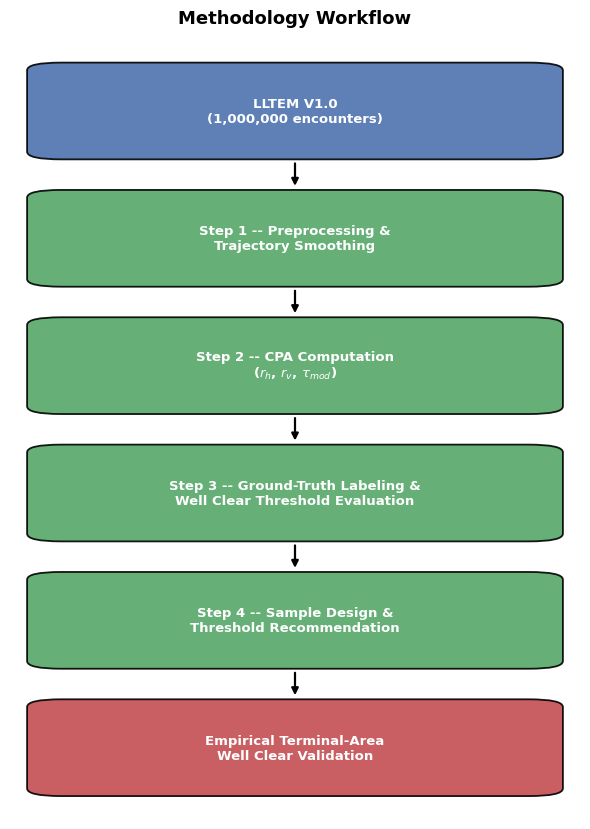

In [18]:
from matplotlib.patches import FancyBboxPatch

steps = [
    ('LLTEM V1.0\n(1,000,000 encounters)', '#4c72b0'),
    ('Step 1 -- Preprocessing &\nTrajectory Smoothing', '#55a868'),
    ('Step 2 -- CPA Computation\n($r_h$, $r_v$, $\\tau_{mod}$)', '#55a868'),
    ('Step 3 -- Ground-Truth Labeling &\nWell Clear Threshold Evaluation', '#55a868'),
    ('Step 4 -- Sample Design &\nThreshold Recommendation', '#55a868'),
    ('Empirical Terminal-Area\nWell Clear Validation', '#c44e52'),
]

box_h, gap = 0.72, 0.28
y_positions = np.arange(len(steps) - 1, -1, -1) * (box_h + gap)

fig, ax = plt.subplots(figsize=(6, 8.4))
for y, (label, color) in zip(y_positions, steps):
    ax.add_patch(FancyBboxPatch((0.05, y - box_h / 2), 0.9, box_h,
                                boxstyle='round,pad=0.02,rounding_size=0.06',
                                linewidth=1.3, edgecolor='black',
                                facecolor=color, alpha=0.9))
    ax.text(0.5, y, label, ha='center', va='center', fontsize=9.5,
            color='white', fontweight='bold')
for y1, y2 in zip(y_positions[:-1], y_positions[1:]):
    ax.annotate('', xy=(0.5, y2 + box_h / 2 + 0.03),
                xytext=(0.5, y1 - box_h / 2 - 0.03),
                arrowprops=dict(arrowstyle='-|>', lw=1.6, color='black'))

ax.set_xlim(0, 1)
ax.set_ylim(y_positions[-1] - box_h / 2 - 0.2, y_positions[0] + box_h / 2 + 0.2)
ax.axis('off')
ax.set_title('Methodology Workflow', fontsize=13, fontweight='bold', pad=12)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'methodology_workflow.pdf')
plt.show()

### Figure 2 — NMAC-severity false-alarm rate vs. TAUMOD

Scored at the fixed NMAC scale, which the configuration's own DMOD and ZTHR
never enter, so a single curve captures the full tested grid. Section 12
verified that directly.

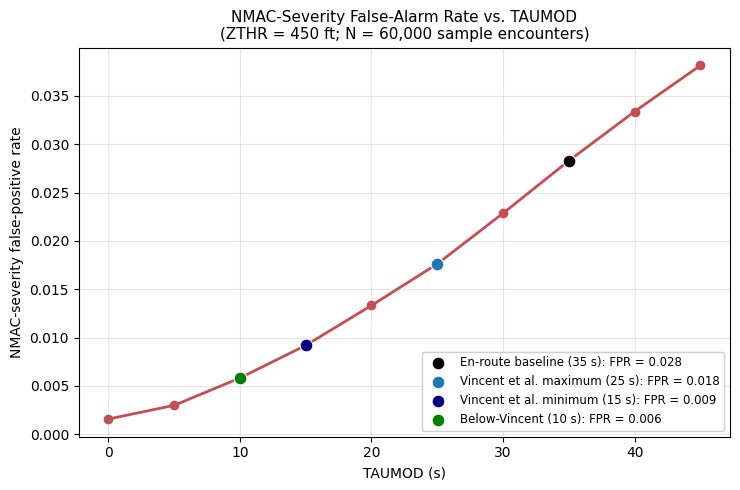

In [19]:
taus = curve['TAUMOD'].values
fpr = curve['FPR_dmod4000'].values

fig, ax = plt.subplots(figsize=(7.5, 5.0))
ax.plot(taus, fpr, marker='o', ms=6, lw=2, color='#c44e52')
for tm, lab, col in [(35, 'En-route baseline (35 s)', 'black'),
                     (25, 'Vincent et al. maximum (25 s)', 'tab:blue'),
                     (15, 'Vincent et al. minimum (15 s)', 'navy'),
                     (10, 'Below-Vincent (10 s)', 'green')]:
    i = int(np.argmin(np.abs(taus - tm)))
    ax.scatter([taus[i]], [fpr[i]], s=85, color=col, zorder=5,
               edgecolor='white', linewidth=0.8,
               label=f'{lab}: FPR = {fpr[i]:.3f}')
ax.set_xlabel('TAUMOD (s)')
ax.set_ylabel('NMAC-severity false-positive rate')
ax.set_title('NMAC-Severity False-Alarm Rate vs. TAUMOD\n'
             f'(ZTHR = 450 ft; N = {len(severity):,} sample encounters)', fontsize=11)
ax.grid(alpha=0.3)
ax.legend(loc='lower right', fontsize=8.5, framealpha=0.92)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'threshold_tradeoff_heatmap.pdf')
plt.show()

### Figure 3 — predicted vs. true severity region, row-normalised

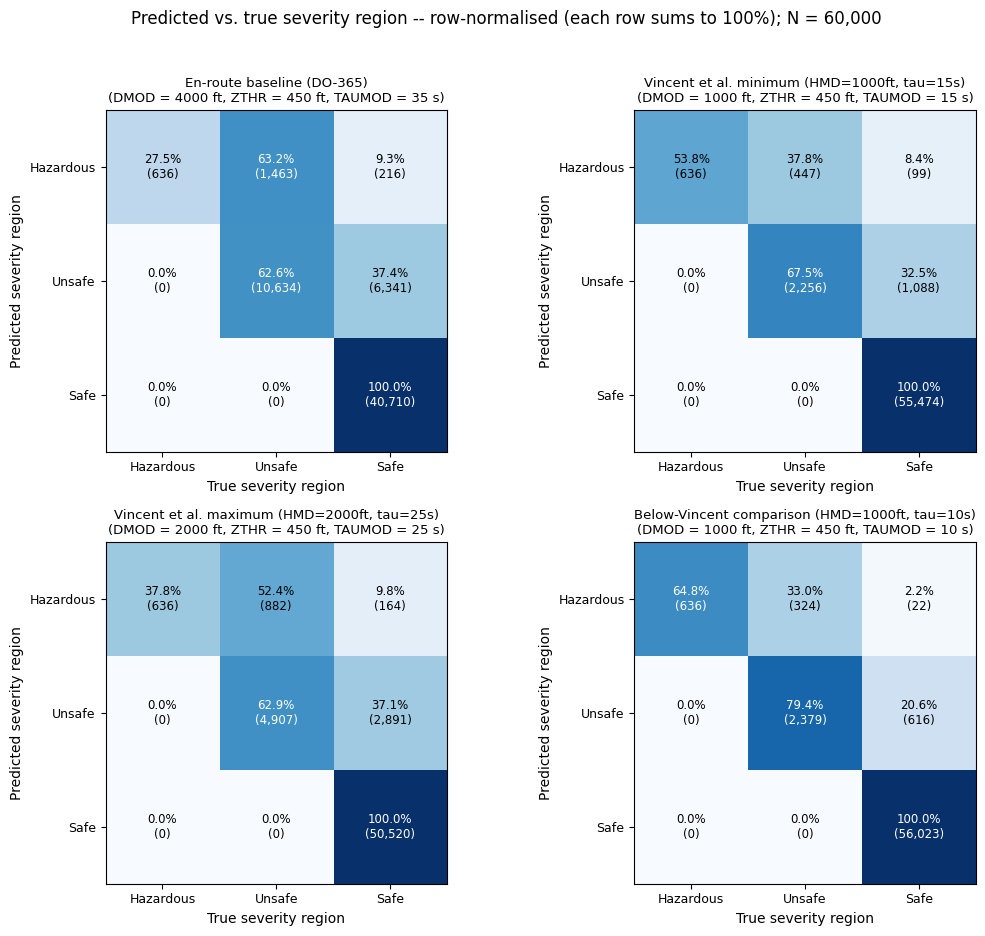

In [20]:
order = ['Hazardous', 'Unsafe', 'Safe']
fig, axes = plt.subplots(2, 2, figsize=(11, 9.5))
for ax, (name, (dmod, zthr, taumod)) in zip(axes.ravel(), wca.NAMED_CONFIGS.items()):
    ct = overall_crosstabs[(name, '__all__')].reindex(index=order,
                                                      columns=order).fillna(0)
    counts = ct.values.astype(float)
    pct = 100 * counts / np.clip(counts.sum(axis=1, keepdims=True), 1, None)
    ax.imshow(pct, cmap='Blues', vmin=0, vmax=100)
    for i in range(3):
        for j in range(3):
            ax.text(j, i, f'{pct[i, j]:.1f}%\n({int(counts[i, j]):,})',
                    ha='center', va='center', fontsize=8.5,
                    color='white' if pct[i, j] > 55 else 'black')
    ax.set_xticks(range(3)); ax.set_xticklabels(order, fontsize=9)
    ax.set_yticks(range(3)); ax.set_yticklabels(order, fontsize=9)
    ax.set_xlabel('True severity region')
    ax.set_ylabel('Predicted severity region')
    ax.set_title(f'{name}\n(DMOD = {dmod:.0f} ft, ZTHR = {zthr:.0f} ft, '
                 f'TAUMOD = {taumod:.0f} s)', fontsize=9.5)
fig.suptitle('Predicted vs. true severity region -- row-normalised '
             f'(each row sums to 100%); N = {len(severity):,}', fontsize=12)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig(FIGURES_DIR / 'confusion_matrix.pdf')
plt.show()

### Figure 4 — alert lead-time distribution

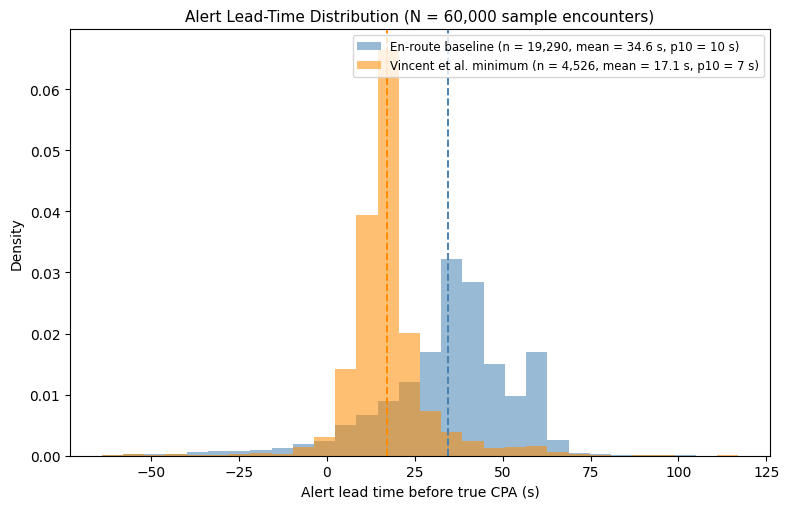

In [21]:
ev_b = wca.evaluate_lowc_batch(stacked, dmod=4000.0, zthr=450.0, taumod=35.0)
ev_v = wca.evaluate_lowc_batch(stacked, dmod=1000.0, zthr=450.0, taumod=15.0)
lb = ev_b['lead_time'][ev_b['any_lowc']]
lv = ev_v['lead_time'][ev_v['any_lowc']]

bins = np.linspace(min(lb.min(), lv.min()), max(lb.max(), lv.max()), 31)
fig, ax = plt.subplots(figsize=(8, 5.2))
ax.hist(lb, bins=bins, alpha=0.55, color='steelblue', density=True,
        label=(f'En-route baseline (n = {len(lb):,}, mean = {lb.mean():.1f} s, '
               f'p10 = {np.percentile(lb, 10):.0f} s)'))
ax.hist(lv, bins=bins, alpha=0.55, color='darkorange', density=True,
        label=(f'Vincent et al. minimum (n = {len(lv):,}, mean = {lv.mean():.1f} s, '
               f'p10 = {np.percentile(lv, 10):.0f} s)'))
ax.axvline(lb.mean(), color='steelblue', ls='--', lw=1.4)
ax.axvline(lv.mean(), color='darkorange', ls='--', lw=1.4)
ax.set_xlabel('Alert lead time before true CPA (s)')
ax.set_ylabel('Density')
ax.set_title(f'Alert Lead-Time Distribution (N = {len(severity):,} sample encounters)',
             fontsize=11)
ax.legend(loc='upper right', fontsize=8.5)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'alert_leadtime_distribution.pdf')
plt.show()